# Summer School - Modeling Water Fluxes In The Soil-Plant System

## Root hydraulics

1. Root water uptake from a static soil 

2. Root hydraulic conductance (Krs)  

3. Standard uptake fraction (SUF)


### 0. Loading libraries

In [2]:
# generic Python libraries
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import SVG, Image, display # to show svg files in the notebook

# specific CPlantBox libraries
search_path = '../lib'
sys.path.append(search_path)
import plantbox as pb #CPlantBox itself
import visualisation.vtk_plot as vp # for quick vizualisations

### Root water uptake from a static soil 
The plant structure can be coupled with inner plant water flow thanks to two new libraries, one for parameters storage and one containing the solver.

In [3]:
from functional.PlantHydraulicParameters import PlantHydraulicParameters  # parameters storage 
from functional.PlantHydraulicModel import HydraulicModel_Doussan # solver

Water flow in the root system is computed according to the xylem water potential gradients between nodes, driven by the boundary condition at the root collar. In other words, the root collar (top of the root system) acts as a hoover that sucks-in the water around the roots.\
At the root collar, either the water potential or the water flux can be prescribed (Dirichlet or Neumann boundary conditions). \
Root water uptake is computed as the sum of the radial fluxes into each root segment, according the the water potential differences between xylem and soil. \
In the example below, we set a constant and uniform total soil water potential, and constant root hydraulic properties. 

Root collar potential -1000 [cm], transpiration -18.9341 [cm3/day]
Root collar potential -669.704 [cm], transpiration -10 [cm3/day]


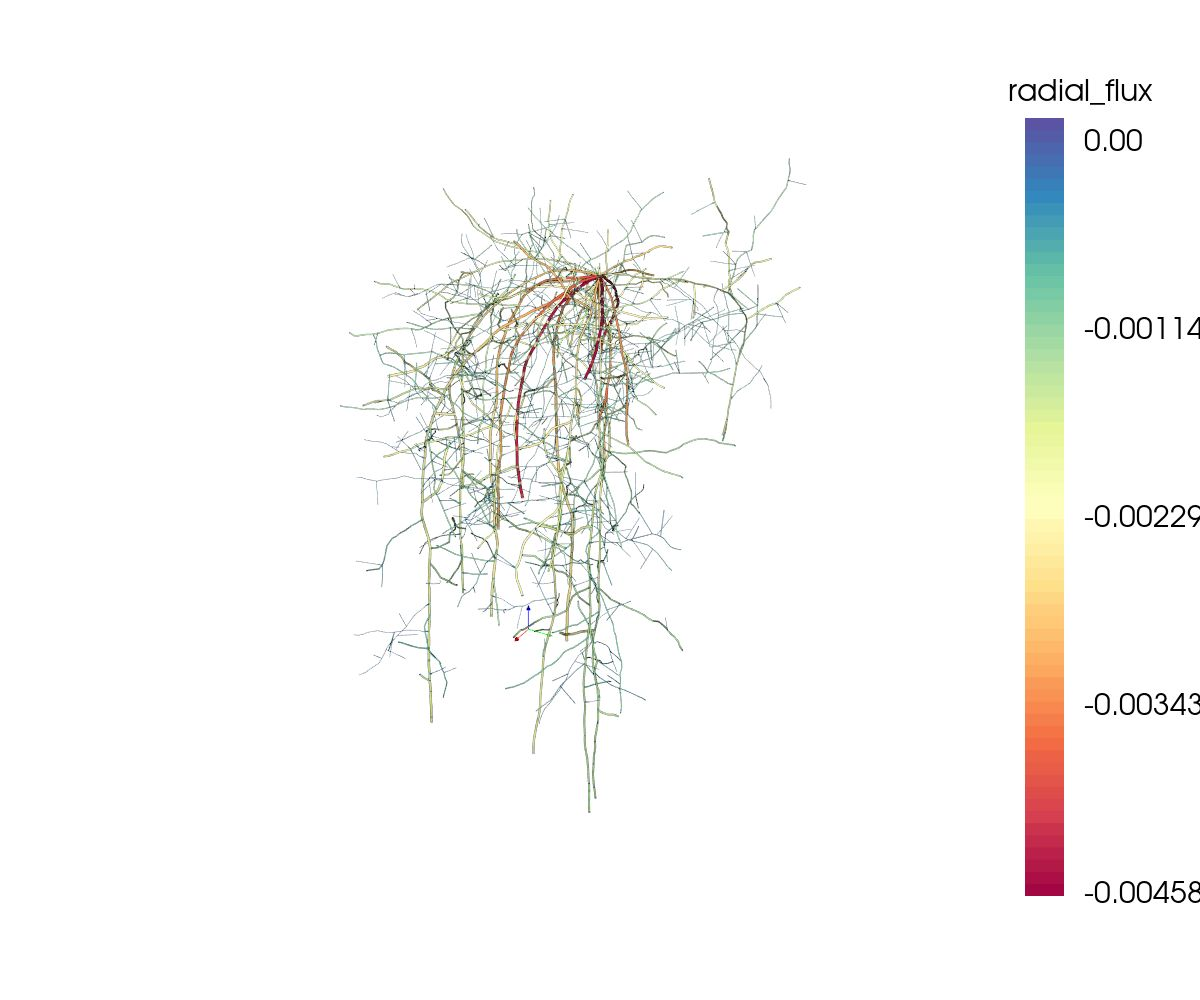

([<vtkmodules.vtkRenderingOpenGL2.vtkOpenGLActor(0x00000153D9CDAB70) at 0x00000153EBFE4F40>,
  <vtkmodules.vtkRenderingOpenGL2.vtkOpenGLActor(0x00000153D9CDADA0) at 0x00000153EBFE5780>],
 <vtkmodules.vtkRenderingAnnotation.vtkScalarBarActor(0x00000153D9D1B000) at 0x00000153EBFE53C0>)

In [3]:
""" Parameters """  # 
initial_age = 14  # root system age [day]
kx = 4.32e-2  # axial conductivity [cm3/day]
kr = 1.728e-4  # radial conductivity [1/day]
Hs = -300  # soil total potential [cm]
h0 = -1000  # dirichlet bc at top [cm] 
t_pot = -10  # potential plant transpiration [cm3/day] 

""" root system """  
plant = pb.MappedPlant()  
path =  "../modelparameter/structural/rootsystem/"
name = "Zeamays_synMRI"
plant.readParameters(path + name + ".xml")
plant.initialize()
plant.simulate(initial_age)  

""" root hydraulic properties """
params = PlantHydraulicParameters()  
params.set_kr_const(kr) # store the conductivity data 
params.set_kx_const(kx)
hm = HydraulicModel_Doussan(plant, params) # create the water flow object

""" Numerical solution """ 
ns = plant.getNumberOfMappedSegments()
hsr = plant.total2matric(Hs * np.ones((ns,)))  # define manually the water potential around the roots
hx = hm.solve_dirichlet(initial_age, h0, hsr, cells = False) 
print("Root collar potential {:g} [cm], transpiration {:g} [cm3/day]".format(hx[0], hm.get_transpiration(initial_age, hx, hsr)))
hx = hm.solve_neumann(initial_age, t_pot, hsr, cells = False)  
print("Root collar potential {:g} [cm], transpiration {:g} [cm3/day]".format(hx[0], hm.get_transpiration(initial_age, hx, hsr)))  # |\label{l41:numerical_end}|

""" Additional vtk plot """
ana = pb.SegmentAnalyser(hm.ms.mappedSegments())  
# we can add any values for visualisation in VTP
ana.addData("hx", hx)  # xylem potentials [cm]
radial_flux = hm.radial_fluxes(initial_age, hx, hsr, cells = False) # "axial_flux" [cm3/day]
ana.addData("radial_flux", radial_flux)  
vp.plot_plant(ana, "radial_flux", interactiveImage = False)  # other options: "axial_flux" "hx"


**Q: Why doe we obtain different results between the Dirichlet and the Neumann boundary condition?**\
The Dirichlet condition fix the water potential at the root collar while the Neumann condition fix the potential transpiration.\
**Q: In the code above, where is the Neumann boundary condition defined?**\
It is defined with _t_pot = -10_.
**Q: Lower and increase the Dirichlet and Neumann boundary conditions. How are the results affected (root collar potential, actual transpiration)?**\
A less negative Dirichlet or Neumann boundary condition will lower both the root collar potential and actual transpiration.\
**Q: Change the plant age, kx, and kr. How do those parameters affect the plant transpiration rate? The water potential at the root collar? Why?**\
Higher plant age, kx and kr lowers the root collar potential (if set Neumann BC) or the actual transpiration (if set Dirichlet BC) as the plant can then take up more easily water from the soil.\
**Q: Where in the root system do we have the highest/lowest water uptake? Is this result realistic?**
We have the highest uptake at the upper part of the root, as this is where we have the lowest plant water potential, increasing the plant-to-soil gradients. This is not very realistic as normally, plant uptake occures mainly near the root tips. This is caused by the fact that we used a constent kr and kx.

In the example below, we use the hm.solve function, which can use both a Dirichlet and a Neumann boundary condition. 
Look at the difference between potential and actual transpiration and at the water potential at the root collar. 

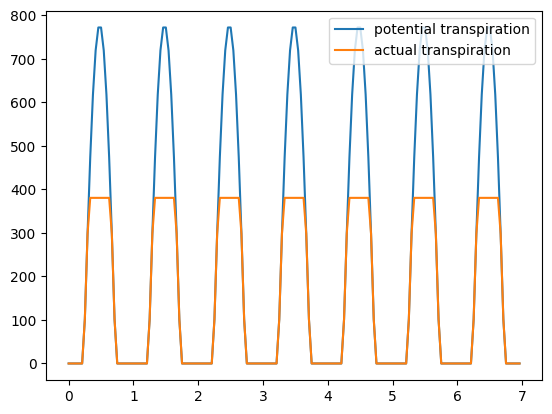

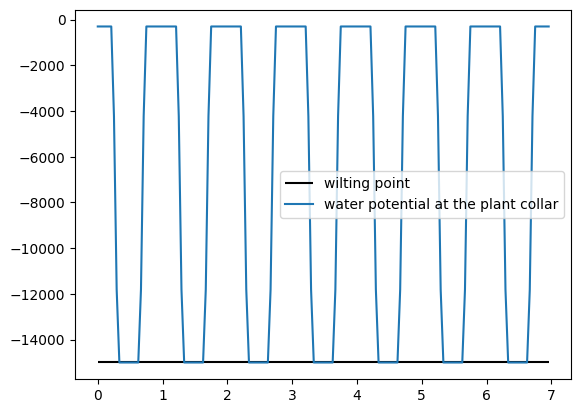

In [4]:
""" Parameters """  
sim_time = 7
dt = 3600./(24.*3600)
initial_age = 14  # root system age [day]
kx = 4.32e-2  # axial conductivity [cm3/day]
kr = 1.728e-4  # radial conductivity [1/day]
Hs = -300  # soil total potential [cm]
t_pot = -250  # potential plant transpiration per day [cm3/day] 

def sinusoidal2(t, dt):
    """ sinusoidal function from 6:00 - 18:00, 0 otherwise (used for transpiration, integral over one day is 1)"""
    return np.maximum(0., np.pi * (np.cos(2 * np.pi * (t - 0.5)) + np.cos(2 * np.pi * ((t + dt) - 0.5))) / 2)

""" root system """  
plant = pb.MappedPlant()  
path = "../modelparameter/structural/rootsystem/"
name = "Zeamays_synMRI"
plant.readParameters(path + name + ".xml")
plant.initialize(False)
plant.simulate(initial_age)  

""" root hydraulic properties """
params = PlantHydraulicParameters()  
params.set_kr_const(kr)
params.set_kx_const(kx)
hm = HydraulicModel_Doussan(plant, params)  

""" Simulation loop """ 
ns = plant.getNumberOfMappedSegments()
hsr = plant.total2matric(Hs * np.ones(ns))  # static uniform total potential defined manually TODO: change that to always get value per cell

N = int(sim_time/dt)
h_collar_ = []
t_act_ = []
for i in range(0, N):
    t = i * dt # current simulation time 
    rx = hm.solve(initial_age, t_pot*sinusoidal2(t,dt), hsr, cells = False)  # uses both a Dirichlet and a Neumann boundary condition
    t_act = hm.get_transpiration(sim_time, rx, hsr, cells = False)
    t_act_.append(t_act)
    h_collar_.append(rx[hm.collar_index_]) # store water potential at the root collar

t = np.linspace(0, (N-1)*dt, N)
plt.plot(t, -t_pot * sinusoidal2(t,dt), label = "potential transpiration")
plt.plot(t, -np.array(t_act_), label = "actual transpiration")
plt.legend()
plt.show()
plt.hlines(hm.wilting_point,xmin = t[0],xmax=t[-1], label = "wilting point",colors='k')
plt.plot(t, h_collar_, label = "water potential at the plant collar")
plt.legend()
plt.show()

**Q: In the code above, th epotential transpiration is sometimes lower than the potential transpiration. What does that mean?**\
The plant cannot fulfill its water requirements.\
**Q: In the simulated days, when is the transpiration set by the Neumann boundary condition? By the Dirichlet boundary condition?**\
When the actual transpiration follows the potential transpiration, we follow the Neumann BC. When the water potential at the root collar is at the wilting point, we follow the Dirichlet BC. In summary, the plant follows its Neumann BC (potential transpiration) until its water potential at the root collar reaches teh wilting point. Then the plant decreases its transpiration so that the water potential at the root collar remains at the wilting point. Once the potential transpiration decreases, the plant can once more follow the Neumann BC.\
**Q: Change the parameters so that the actual transpiration is always equal to the potential transpiration.**\
Several solution are possible:
- make the plant water uptake easier:
    - increase kr
    - increase kx
    - increase the plant age (which will increase the plant root surface)
    - make the soil water potential less negative (limited effect in our example)
- lower the potential transpiration

In the example below we increased the kr and kx (to unrealistic values).

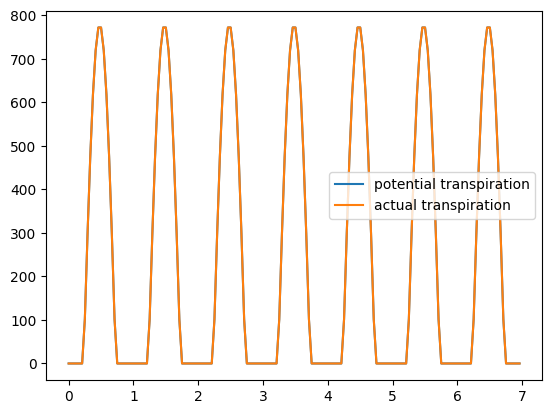

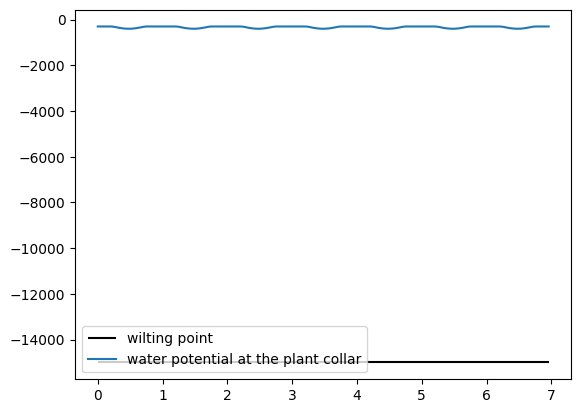

In [7]:
""" Parameters """  
sim_time = 7
dt = 3600./(24.*3600)
initial_age = 14  # root system age [day]
kx = 4.32  # axial conductivity [cm3/day]
kr = 1.728  # radial conductivity [1/day]
Hs = -300  # soil total potential [cm]
t_pot = -250  # potential plant transpiration per day [cm3/day] 

def sinusoidal2(t, dt):
    """ sinusoidal function from 6:00 - 18:00, 0 otherwise (used for transpiration, integral over one day is 1)"""
    return np.maximum(0., np.pi * (np.cos(2 * np.pi * (t - 0.5)) + np.cos(2 * np.pi * ((t + dt) - 0.5))) / 2)

""" root system """  
plant = pb.MappedPlant()  
path = "../modelparameter/structural/rootsystem/"
name = "Zeamays_synMRI"
plant.readParameters(path + name + ".xml")
plant.initialize(False)
plant.simulate(initial_age)  

""" root hydraulic properties """
params = PlantHydraulicParameters()  
params.set_kr_const(kr)
params.set_kx_const(kx)
hm = HydraulicModel_Doussan(plant, params)  

""" Simulation loop """ 
ns = plant.getNumberOfMappedSegments()
hsr = plant.total2matric(Hs * np.ones(ns))  # static uniform total potential defined manually TODO: change that to always get value per cell

N = int(sim_time/dt)
h_collar_ = []
t_act_ = []
for i in range(0, N):
    t = i * dt # current simulation time 
    rx = hm.solve(initial_age, t_pot*sinusoidal2(t,dt), hsr, cells = False)  # uses both a Dirichlet and a Neumann boundary condition
    t_act = hm.get_transpiration(sim_time, rx, hsr, cells = False)
    t_act_.append(t_act)
    h_collar_.append(rx[hm.collar_index_]) # store water potential at the root collar

t = np.linspace(0, (N-1)*dt, N)
plt.plot(t, -t_pot * sinusoidal2(t,dt), label = "potential transpiration")
plt.plot(t, -np.array(t_act_), label = "actual transpiration")
plt.legend()
plt.show()
plt.hlines(hm.wilting_point,xmin = t[0],xmax=t[-1], label = "wilting point",colors='k')
plt.plot(t, h_collar_, label = "water potential at the plant collar")
plt.legend()
plt.show()

The conductivities can be given as a constant for the whole root system (see previous examples), for each root subtype, for each segment, or according to the root age. In the example below, conductivity varies with the root age.\
The graphic show the radial and axial conductivites according to the age of the root segment.\
**Q: in the code below change the value of the input parameters to make the radial conductances reach their final (lowest) values at day 20.**\
**Q: in the code below change the value of the input parameters to make the axial conductances reach their final (highest) values at day 20.**\
Several solutions are possible. We give an example below.

0.357
0.00411

SubType 0 for negative age: kx = 0.0001, kr = 0.0001
SubType 0 for old root age: kx = 0.0001, kr = 0.0001
SubType 1 for negative age: kx = 0.0674, kr = 0.00114
SubType 1 for old root age: kx = 0.357, kr = 0.000517
SubType 2 for negative age: kx = 0.000407, kr = 0.00411
SubType 2 for old root age: kx = 0.0136, kr = 0.00158
SubType 3 for negative age: kx = 0.000407, kr = 0.00411
SubType 3 for old root age: kx = 0.0136, kr = 0.00158
SubType 4 for negative age: kx = 0.0674, kr = 0.00114
SubType 4 for old root age: kx = 0.357, kr = 0.000517



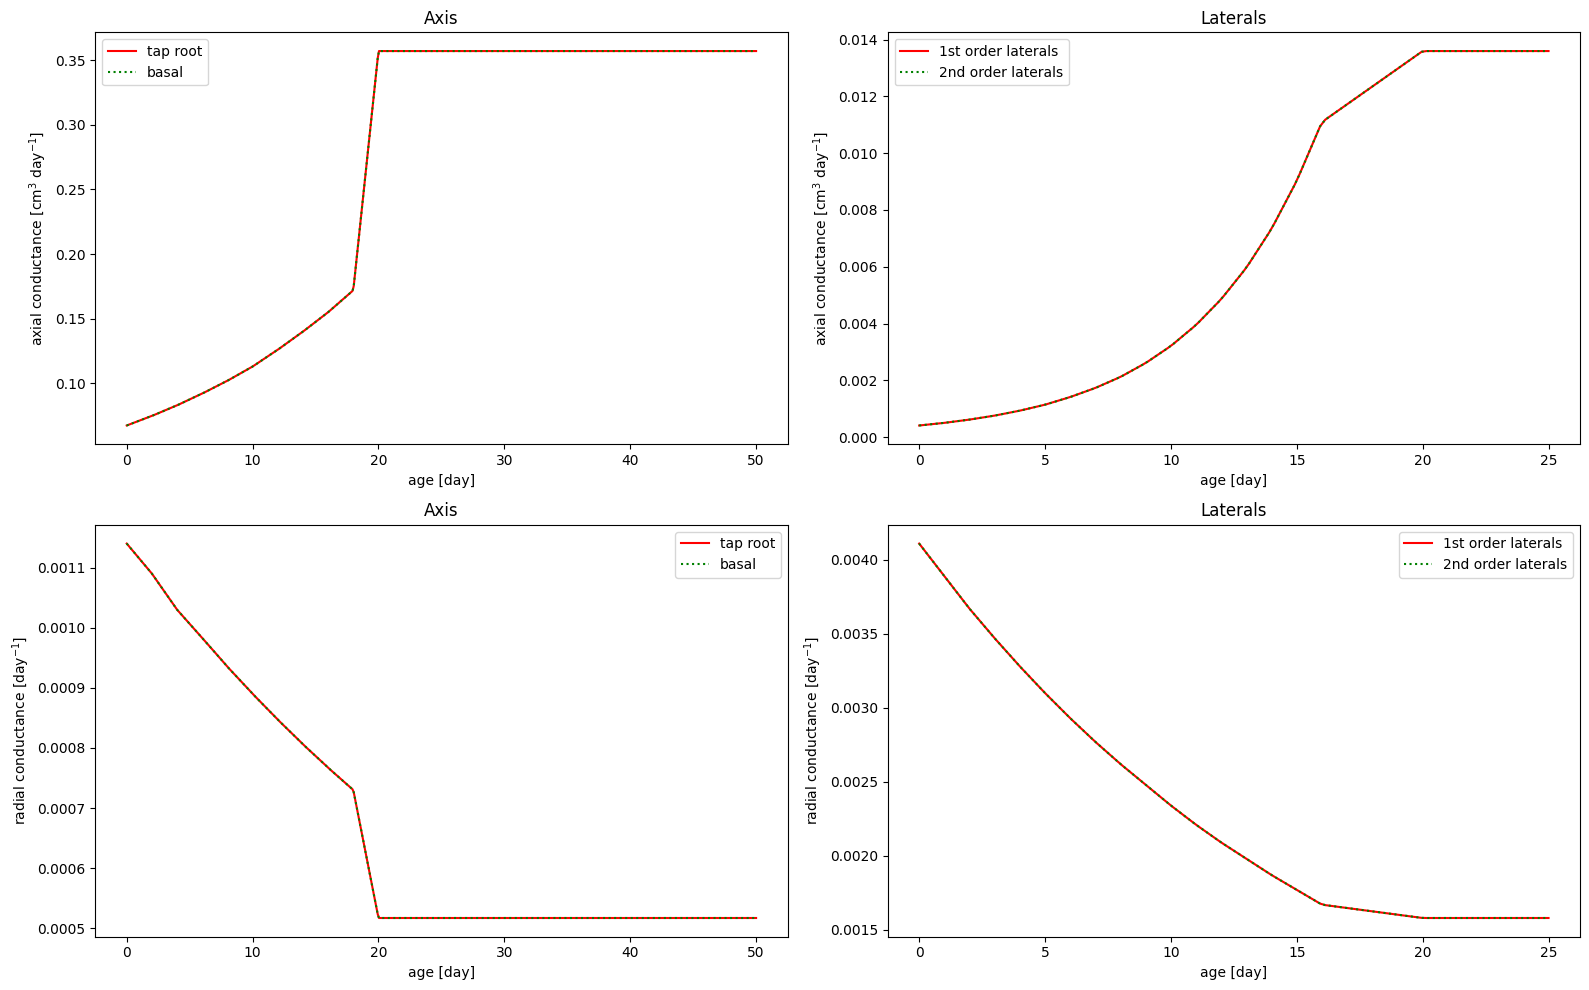

In [9]:
param = PlantHydraulicParameters()
param = PlantHydraulicParameters()

# ---- kr ----
kr0_age = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
kr0_values = np.array([1.14e-03, 1.09e-03, 1.03e-03, 9.83e-04, 9.35e-04,
                       8.90e-04, 8.47e-04, 8.06e-04, 7.67e-04, 7.30e-04,
                       5.17e-04])

kr1_age = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                    14, 15, 16, 20])
kr1_values = np.array([4.11e-03, 3.89e-03, 3.67e-03, 3.47e-03, 3.28e-03,
                       3.10e-03, 2.93e-03, 2.77e-03, 2.62e-03, 2.48e-03,
                       2.34e-03, 2.21e-03, 2.09e-03, 1.98e-03, 1.87e-03,
                       1.77e-03, 1.67e-03, 1.58e-03])

param.set_kr_age_dependent(kr0_age, kr0_values, subType=[1, 4])
param.set_kr_age_dependent(kr1_age, kr1_values, subType=[2, 3])


# ---- kx ----
kx0_age = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
kx0_values = np.array([6.74e-02, 7.48e-02, 8.30e-02, 9.21e-02, 1.02e-01,
                       1.13e-01, 1.26e-01, 1.40e-01, 1.55e-01, 1.72e-01,
                       3.57e-01])

kx1_age = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                    14, 15, 16, 20])
kx1_values = np.array([4.07e-04, 5.00e-04, 6.15e-04, 7.56e-04, 9.30e-04,
                       1.14e-03, 1.41e-03, 1.73e-03, 2.12e-03, 2.61e-03,
                       3.21e-03, 3.95e-03, 4.86e-03, 5.97e-03, 7.34e-03,
                       9.03e-03, 1.11e-02, 1.36e-02])

param.set_kx_age_dependent(kx0_age, kx0_values, subType=[1, 4])
param.set_kx_age_dependent(kx1_age, kx1_values, subType=[2, 3])

_ = param.plot_conductivities(axes_ind=[1, 4], lateral_ind=[2, 3])

### Root hydraulic conductance (Krs) 

The code below computes the root system conductance (Krs) for different root architectures over time.

**Q: define in you own word the  root system conductance**\
It is the aggregated conductane of the whole root system.\
**Q: Looking at the outputs below, Do you see a link between total root system length and final Krs? Between total surface of the root system and final Krs? Can you explain why?**\
The Krs will increase the the root surface area as it increases the area that can take up water. Root length does necesserally increase the Krs as more length also means more axial resistance to bring the water to the root collar. Root length can increase the Krs in that it can indicate more root surface.\
**Q: Uncomment the lines below 'Exercise: change parameters'. Change the parameters to increase the plant Krs. Which other parameters can you change?**\
We can increase the amount of root surface by giving a higher lmax and a lower ln for the tap root. We could also increase the root radii.


Simulating: Heliantus_Pages_2014

Simulating: Glycine_max_Moraes2020

Simulating: Brassica_oleracea_Vansteenkiste_2014


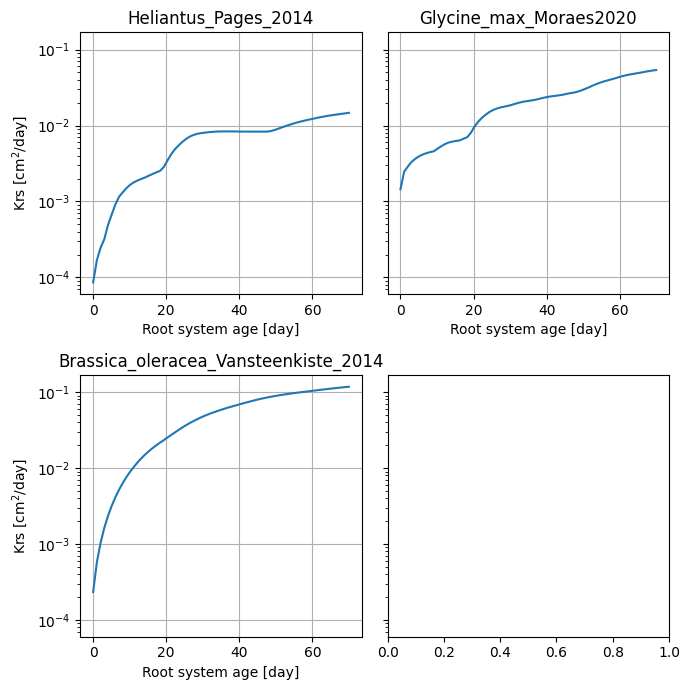


Summary:
Heliantus_Pages_2014 | Total root length: 17000.19 cm | Surface area:  1153.70 cm2
Glycine_max_Moraes2020 | Total root length: 80052.82 cm | Surface area: 11836.04 cm2
Brassica_oleracea_Vansteenkiste_2014 | Total root length: 28097.80 cm | Surface area:  2427.57 cm2


In [10]:
sim_time = 70  
dt = 1

architectures = [  
    "Heliantus_Pages_2014",
    "Glycine_max_Moraes2020",
    "Brassica_oleracea_Vansteenkiste_2014"
]

path = "../modelparameter/structural/rootsystem/"  

""" Root hydraulic properties """  
param = PlantHydraulicParameters()
# ---- kr ----
kr0_age = np.array([0., 12.5, 20.9, 44.6, 62.7, 100.])
kr0_values = np.array([2.2e-4, 2.2e-4, 8.0e-5, 8.0e-5, 1.9e-5, 1.9e-5])

kr1_age = np.array([0., 10., 15., 25.])
kr1_values = np.array([1.8e-4, 1.8e-4, 1.7e-5, 1.7e-5])

param.set_kr_age_dependent(kr0_age, kr0_values, subType=[1, 4])
param.set_kr_age_dependent(kr1_age, kr1_values, subType=[2, 3])


# ---- kx ----
kx0_age = np.array([0., 18.3, 21., 47., 61., 100.])
kx0_values = np.array([2.7e-2, 2.7e-2, 3.3e-1, 3.3e-1, 4.2, 4.2])

kx1_age = np.array([0., 9., 13., 20., 25.])
kx1_values = np.array([1.e-4, 2.e-4, 6.e-4, 1.73e-3, 1.73e-3])

param.set_kx_age_dependent(kx0_age, kx0_values, subType=[1, 4])
param.set_kx_age_dependent(kx1_age, kx1_values, subType=[2, 3])

""" Simulation loop""" 
krs_all, lengths, surfaces  = [], [], []

for name in architectures:
    print(f"\nSimulating: {name}")

    plant = pb.MappedPlant()  
    plant.readParameters(path + name + ".xml")

    """ Exercise: change parameters """   
    random_parameters = plant.getOrganRandomParameter(pb.root) # selecting the root parameters
    # random_parameter_tap_root = random_parameters[1]
    # print('initial tap root parameters: lmax', random_parameter_tap_root.lmax, 'ln', random_parameter_tap_root.ln)
    # random_parameter_tap_root.lmax = 
    # random_parameter_tap_root.ln = 
    
    plant.initialize(False)

    hm = HydraulicModel_Doussan(plant, param) 
    krs_values = []
    arch_lengths = []
    arch_surfaces = []
    N = int(sim_time/dt)
    for i in range(0, N):
        plant.simulate(dt)    
        krs, _ = hm.get_krs(i*dt)
        krs_values.append(krs)  
        total_length = np.sum(np.array(plant.getParameter("length")))
        total_surface = np.sum(np.array(plant.getParameter("surface")))
        arch_lengths.append(total_length)
        arch_surfaces.append(total_surface)        

    krs_all.append(krs_values)
    lengths.append(arch_lengths[-1])  # final length
    surfaces.append(arch_surfaces[-1])  # final surface 

""" Plot """  
fig, axes = plt.subplots(2, 2, figsize = (7,7), sharey = True)
for i in range(len(architectures)):
    ax = axes.flat[i]
    ax.plot(np.linspace(0, sim_time,N), krs_all[i])
    ax.set_title(architectures[i])
    ax.set_xlabel("Root system age [day]")
    ax.set_yscale("log")
    if i%2 == 0:
        ax.set_ylabel("Krs [cm$^2$/day]")
    ax.grid(True)
plt.tight_layout()
plt.show()  

print("\nSummary:")
for i, name in enumerate(architectures):
    print(f"{name:20s} | Total root length: {lengths[i]:8.2f} cm | Surface area: {surfaces[i]:8.2f} cm2")

With the updated parameters:


Simulating: Heliantus_Pages_2014
initial tap root parameters: lmax 101.46 ln 0.40000001
new tap root parameters: lmax 202.92 ln 0.200000005

Simulating: Glycine_max_Moraes2020
initial tap root parameters: lmax 197.35001 ln 0.64999998
new tap root parameters: lmax 394.70002 ln 0.32499999

Simulating: Brassica_oleracea_Vansteenkiste_2014
initial tap root parameters: lmax 200.0 ln 0.40000001
new tap root parameters: lmax 400.0 ln 0.200000005


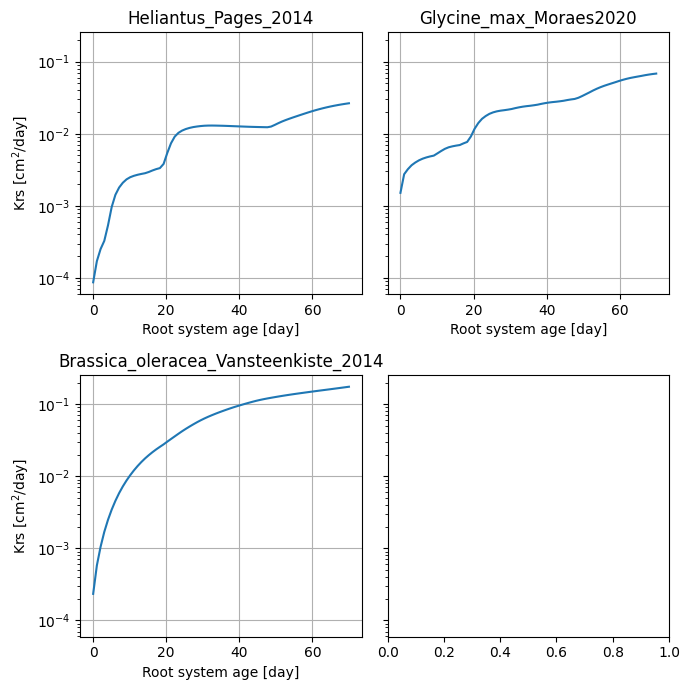


Summary:
Heliantus_Pages_2014 | Total root length: 44423.47 cm | Surface area:  3005.48 cm2
Glycine_max_Moraes2020 | Total root length: 179612.70 cm | Surface area: 26311.36 cm2
Brassica_oleracea_Vansteenkiste_2014 | Total root length: 57838.29 cm | Surface area:  4529.80 cm2


In [11]:
sim_time = 70  
dt = 1

architectures = [  
    "Heliantus_Pages_2014",
    "Glycine_max_Moraes2020",
    "Brassica_oleracea_Vansteenkiste_2014"
]

path = "../modelparameter/structural/rootsystem/"  

""" Root hydraulic properties """  
param = PlantHydraulicParameters()
# ---- kr ----
kr0_age = np.array([0., 12.5, 20.9, 44.6, 62.7, 100.])
kr0_values = np.array([2.2e-4, 2.2e-4, 8.0e-5, 8.0e-5, 1.9e-5, 1.9e-5])

kr1_age = np.array([0., 10., 15., 25.])
kr1_values = np.array([1.8e-4, 1.8e-4, 1.7e-5, 1.7e-5])

param.set_kr_age_dependent(kr0_age, kr0_values, subType=[1, 4])
param.set_kr_age_dependent(kr1_age, kr1_values, subType=[2, 3])


# ---- kx ----
kx0_age = np.array([0., 18.3, 21., 47., 61., 100.])
kx0_values = np.array([2.7e-2, 2.7e-2, 3.3e-1, 3.3e-1, 4.2, 4.2])

kx1_age = np.array([0., 9., 13., 20., 25.])
kx1_values = np.array([1.e-4, 2.e-4, 6.e-4, 1.73e-3, 1.73e-3])

param.set_kx_age_dependent(kx0_age, kx0_values, subType=[1, 4])
param.set_kx_age_dependent(kx1_age, kx1_values, subType=[2, 3])

""" Simulation loop""" 
krs_all, lengths, surfaces  = [], [], []

for name in architectures:
    print(f"\nSimulating: {name}")

    plant = pb.MappedPlant()  
    plant.readParameters(path + name + ".xml")

    """ Exercise: change parameters """   
    random_parameters = plant.getOrganRandomParameter(pb.root) # selecting the root parameters
    random_parameter_tap_root = random_parameters[1]
    print('initial tap root parameters: lmax', random_parameter_tap_root.lmax, 'ln', random_parameter_tap_root.ln)
    random_parameter_tap_root.lmax = random_parameter_tap_root.lmax * 2.
    random_parameter_tap_root.ln = random_parameter_tap_root.ln / 2.
    print('new tap root parameters: lmax', random_parameter_tap_root.lmax, 'ln', random_parameter_tap_root.ln)
    
    plant.initialize(False)

    hm = HydraulicModel_Doussan(plant, param) 
    krs_values = []
    arch_lengths = []
    arch_surfaces = []
    N = int(sim_time/dt)
    for i in range(0, N):
        plant.simulate(dt)    
        krs, _ = hm.get_krs(i*dt)
        krs_values.append(krs)  
        total_length = np.sum(np.array(plant.getParameter("length")))
        total_surface = np.sum(np.array(plant.getParameter("surface")))
        arch_lengths.append(total_length)
        arch_surfaces.append(total_surface)        

    krs_all.append(krs_values)
    lengths.append(arch_lengths[-1])  # final length
    surfaces.append(arch_surfaces[-1])  # final surface 

""" Plot """  
fig, axes = plt.subplots(2, 2, figsize = (7,7), sharey = True)
for i in range(len(architectures)):
    ax = axes.flat[i]
    ax.plot(np.linspace(0, sim_time,N), krs_all[i])
    ax.set_title(architectures[i])
    ax.set_xlabel("Root system age [day]")
    ax.set_yscale("log")
    if i%2 == 0:
        ax.set_ylabel("Krs [cm$^2$/day]")
    ax.grid(True)
plt.tight_layout()
plt.show()  

print("\nSummary:")
for i, name in enumerate(architectures):
    print(f"{name:20s} | Total root length: {lengths[i]:8.2f} cm | Surface area: {surfaces[i]:8.2f} cm2")

### Standard uptake fraction (SUF)
The code below computes for each plant the standard uptake fraction. \
**Q: defines in you own word the standard uptake fraction**\
The standard uptake fraction (SUF) is the fraction of the total root water uptake that is taken up per root segment with a constant soil water potential. The SUF can be summed per types of roots, area of soil or other. In the example below, it is summed for each soil depth value.
**Q: Looking at the outputs below, which root system can profit the most quickly from rainfall water?**\
The root system which has teh highest part of its SUF in the upper soil layers will be better able to use rainfall water. Here the three plants ahve similar SUF near the soil surface but the Glycine has the highes SUF values durectly under the surface. So it might profit more quickly from the rainfall water. \
**Q: Uncomment the lines below 'Exercise: change parameters'. Change the parameters to shift the SUF towards the soil's upper layer. Which other parameters can you change?**\
We could lower the plant length to make sure that the roots are all in the upper layer. We could also increase the root apical length or lower the strength of the gravitropism.


Simulating: Heliantus_Pages_2014

Simulating: Glycine_max_Moraes2020

Simulating: Brassica_oleracea_Vansteenkiste_2014


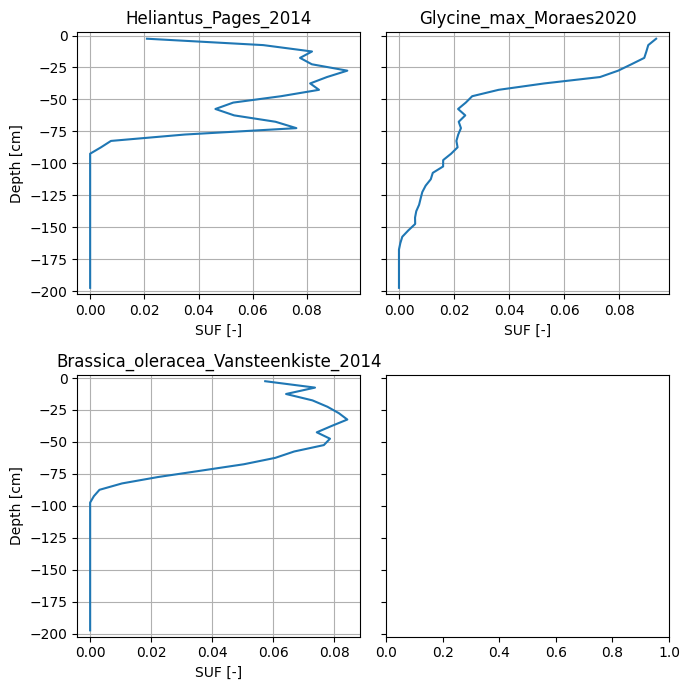

In [14]:
""" Simulation loop""" 
suf_profiles = [] # To store SUF depth profiles for all architectures at final sim_time

architectures = [  
    "Heliantus_Pages_2014",
    "Glycine_max_Moraes2020" ,
    "Brassica_oleracea_Vansteenkiste_2014"
]
path = "../modelparameter/structural/rootsystem/"  
for name in architectures:
    print(f"\nSimulating: {name}")

    plant = pb.MappedPlant()  
    plant.readParameters(path + name + ".xml")
    
    """ Exercise: change parameters """   
    # random_parameters = plant.getOrganRandomParameter(pb.root) # selecting the root parameters
    # random_parameter_tap_root = random_parameters[1]
    # print('initial tap root parameters: lmax', random_parameter_tap_root.lmax, 'ln', random_parameter_tap_root.ln)
    # random_parameter_tap_root.lmax = 
    # random_parameter_tap_root.ln = 
    
    plant.initialize()    
    hm = HydraulicModel_Doussan(plant, param)  # param from example before
    plant.simulate(sim_time)

    suf = hm.get_suf(sim_time)  # suf value per segment
    ana = pb.SegmentAnalyser(plant) # See end of notebook 1 to learn more about SegmentAnalyser
    ana.addData("SUF", suf)  # suf at each segment in the 3d space

    bin_size = 5  # soil layer thickness is defined, for plotting purposes
    z_max = 0
    z_min = -200
    n_bins = int((z_max - z_min) / bin_size)
    suf_dist = ana.distribution("SUF", z_max, z_min, n_bins, True)   # suf value per soil layer

    depths = np.linspace(z_max - bin_size / 2, z_min + bin_size / 2, n_bins)  
    suf_array = np.array(suf_dist)
    depth_array = np.array(depths)
    
    suf_profiles.append((suf_array, depth_array)) # for plotting

""" Plotting """
fig_suf, axes_suf = plt.subplots(2, 2, figsize = (7,7), sharey = True)  

for i in range(len(architectures)):
    ax = axes_suf.flat[i]
    suf, depth = suf_profiles[i]
    ax.plot(suf, depth)
    ax.set_xlabel("SUF [-]")
    if i % 2 == 0:
        ax.set_ylabel("Depth [cm]")
    ax.grid(True)
    ax.set_title(architectures[i])
    if len(depth) > 0:
        ax.set_ylim(depth.min() - 5, depth.max() + 5)  # optional padding

plt.tight_layout()
plt.show()  

With the updated parameters:


Simulating: Heliantus_Pages_2014
initial tap root parameters: lmax 101.46 ln 0.40000001

Simulating: Glycine_max_Moraes2020
initial tap root parameters: lmax 197.35001 ln 0.64999998

Simulating: Brassica_oleracea_Vansteenkiste_2014
initial tap root parameters: lmax 200.0 ln 0.40000001


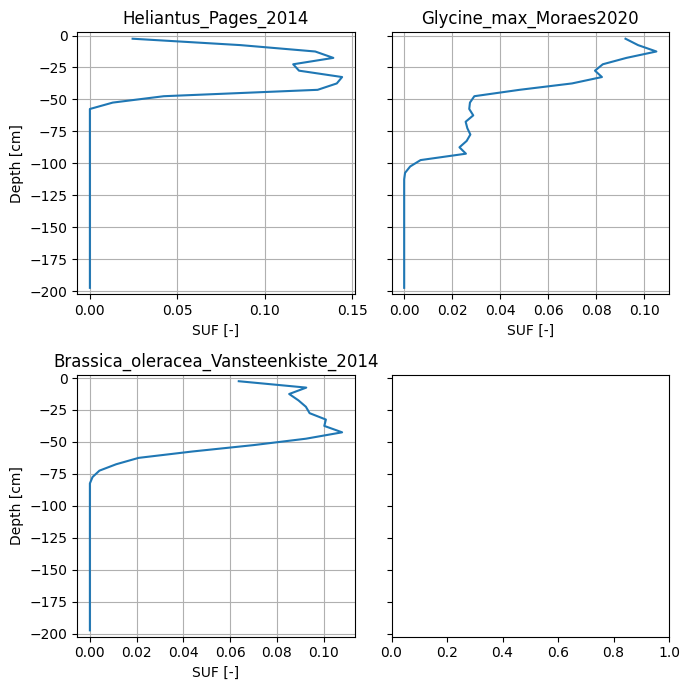

In [15]:
""" Simulation loop""" 
suf_profiles = [] # To store SUF depth profiles for all architectures at final sim_time

architectures = [  
    "Heliantus_Pages_2014",
    "Glycine_max_Moraes2020" ,
    "Brassica_oleracea_Vansteenkiste_2014"
]
path = "../modelparameter/structural/rootsystem/"  
for name in architectures:
    print(f"\nSimulating: {name}")

    plant = pb.MappedPlant()  
    plant.readParameters(path + name + ".xml")
    
    """ Exercise: change parameters """   
    random_parameters = plant.getOrganRandomParameter(pb.root) # selecting the root parameters
    random_parameter_tap_root = random_parameters[1]
    print('initial tap root parameters: lmax', random_parameter_tap_root.lmax, 'ln', random_parameter_tap_root.ln)
    random_parameter_tap_root.lmax = random_parameter_tap_root.lmax/2.
    print('new tap root parameters: lmax', random_parameter_tap_root.lmax, 'ln', random_parameter_tap_root.ln)
    
    plant.initialize()    
    hm = HydraulicModel_Doussan(plant, param)  # param from example before
    plant.simulate(sim_time)

    suf = hm.get_suf(sim_time)  # suf value per segment
    ana = pb.SegmentAnalyser(plant) # See end of notebook 1 to learn more about SegmentAnalyser
    ana.addData("SUF", suf)  # suf at each segment in the 3d space

    bin_size = 5  # soil layer thickness is defined, for plotting purposes
    z_max = 0
    z_min = -200
    n_bins = int((z_max - z_min) / bin_size)
    suf_dist = ana.distribution("SUF", z_max, z_min, n_bins, True)   # suf value per soil layer

    depths = np.linspace(z_max - bin_size / 2, z_min + bin_size / 2, n_bins)  
    suf_array = np.array(suf_dist)
    depth_array = np.array(depths)
    
    suf_profiles.append((suf_array, depth_array)) # for plotting

""" Plotting """
fig_suf, axes_suf = plt.subplots(2, 2, figsize = (7,7), sharey = True)  

for i in range(len(architectures)):
    ax = axes_suf.flat[i]
    suf, depth = suf_profiles[i]
    ax.plot(suf, depth)
    ax.set_xlabel("SUF [-]")
    if i % 2 == 0:
        ax.set_ylabel("Depth [cm]")
    ax.grid(True)
    ax.set_title(architectures[i])
    if len(depth) > 0:
        ax.set_ylim(depth.min() - 5, depth.max() + 5)  # optional padding

plt.tight_layout()
plt.show()  

## Advanced: 
**Q: compute yourself the plant Krs. You should get the same result as the one given by the function hm.get_krs( sim_time).**\
Hint: the equation to get the Krs is:\
Krs = transpiration / ( potential at the root collar - effective soil water potential)\
Note: you can try and change the soil potential or the potential transpiration, the Krs should remain the same.

In [23]:
sim_time = 70  
name = "Brassica_oleracea_Vansteenkiste_2014"
path = "../modelparameter/structural/rootsystem/"  

""" Root hydraulic properties """  
param = PlantHydraulicParameters()

kr0 = np.array([[0., 2.2e-4], [12.5, 2.2e-4], [20.9, 8.0e-5], [44.6, 8.0e-5], [62.7, 1.9e-5], [100, 1.9e-5]])
kr1 = np.array([[0., 1.8e-4], [10, 1.8e-4], [15, 1.7e-5], [25, 1.7e-5]])
param.set_kr_age_dependent(kr0[:, 0], kr0[:, 1], subType = [1, 4])  
param.set_kr_age_dependent(kr1[:, 0], kr1[:, 1], subType = [2, 3])

kx0 = np.array([[0, 2.7e-2], [18.3, 2.7e-2], [21, 3.3e-1], [47, 3.3e-1], [61, 4.2], [100, 4.2]])
kx1 = np.array([[0, 1.e-4], [9, 2.e-4], [13, 6.e-4], [20, 1.73e-3], [25, 1.73e-3]])
param.set_kx_age_dependent(kx0[:, 0], kx0[:, 1], subType = [1, 4])
param.set_kx_age_dependent(kx1[:, 0], kx1[:, 1], subType = [2, 3]) 


plant = pb.MappedPlant(1)  
plant.readParameters(path + name + ".xml")
plant.initialize(False)

hm = HydraulicModel_Doussan(plant, param) 
plant.simulate(sim_time) 
krs, _ = hm.get_krs( sim_time)
print("Krs [cm2/day]:",krs) 


hs_total = -200.
hsx_total = np.ones(hm.ms.getNumberOfMappedSegments()) * (hs_total)
suf = hm.get_suf(sim_time)
heff = suf.dot(hsx_total)
hx = hm.solve_dirichlet(sim_time, -15000, hm.ms.total2matric(hsx_total), cells = False)
t_act = -hm.get_transpiration(sim_time, hx, hm.ms.total2matric(hsx_total), cells = False)
hx_collar = hx[hm.collar_index()]
Krs = t_act/(heff - hx_collar) ## <== solution
print("Krs [cm2/day], recalculated:",Krs) 

Krs [cm2/day]: 0.11767632307547603
Krs [cm2/day], recalculated: 0.11770066990093934


## Advanced: 
**Q: Look at the code below. The last section of the code is commented out. Uncomment the code and using the radial_fluxes array recompute the suf array called 'suf_3d'**

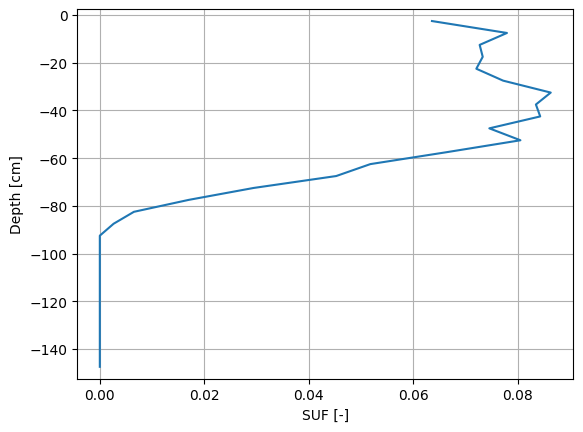

(-152.5, 2.5)

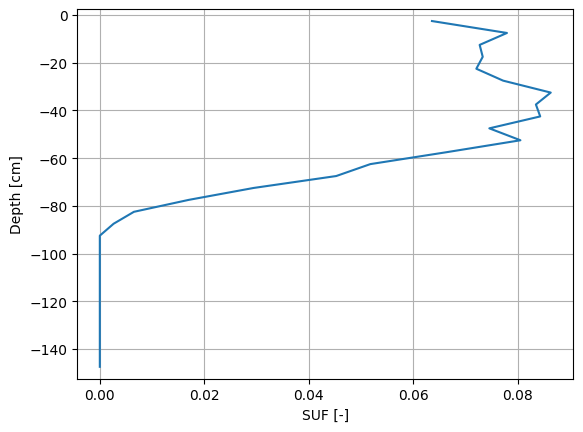

In [25]:
sim_time = 70  
name = "Brassica_oleracea_Vansteenkiste_2014"
path = "../modelparameter/structural/rootsystem/"  

""" Root hydraulic properties """  
param = PlantHydraulicParameters()

kr0 = np.array([[0., 2.2e-4], [12.5, 2.2e-4], [20.9, 8.0e-5], [44.6, 8.0e-5], [62.7, 1.9e-5], [100, 1.9e-5]])
kr1 = np.array([[0., 1.8e-4], [10, 1.8e-4], [15, 1.7e-5], [25, 1.7e-5]])
param.set_kr_age_dependent(kr0[:, 0], kr0[:, 1], subType = [1, 4])  
param.set_kr_age_dependent(kr1[:, 0], kr1[:, 1], subType = [2, 3])

kx0 = np.array([[0, 2.7e-2], [18.3, 2.7e-2], [21, 3.3e-1], [47, 3.3e-1], [61, 4.2], [100, 4.2]])
kx1 = np.array([[0, 1.e-4], [9, 2.e-4], [13, 6.e-4], [20, 1.73e-3], [25, 1.73e-3]])
param.set_kx_age_dependent(kx0[:, 0], kx0[:, 1], subType = [1, 4])
param.set_kx_age_dependent(kx1[:, 0], kx1[:, 1], subType = [2, 3]) 


plant = pb.MappedPlant(1)  
plant.readParameters(path + name + ".xml")
plant.initialize(False)

hm = HydraulicModel_Doussan(plant, param) 
plant.simulate(sim_time) 


def get_1d_from_3d_suf(hm, suf):    
    ana = pb.SegmentAnalyser(hm.ms)
    ana.addData("SUF", suf)  # suf at each segment in the 3d space
    
    bin_size = 5  # soil layer thickness is defined, for plotting purposes
    z_max = 0
    z_min = -150
    n_bins = int((z_max - z_min) / bin_size)
    suf_dist = ana.distribution("SUF", z_max, z_min, n_bins, True)  
    
    depths = np.linspace(z_max - bin_size / 2, z_min + bin_size / 2, n_bins)  
    suf_array = np.array(suf_dist)
    depth_array = np.array(depths)
    return suf_array, depth_array


def get_variables_for_suf(hm, time):
    n = hm.ms.getNumberOfMappedSegments()
    rsx = np.ones(n) * (-500)
    rsx = hm.ms.total2matric(rsx)
    rx = hm.solve_dirichlet(sim_time, -15000, rsx, cells = False)
    q = hm.radial_fluxes(sim_time, rx, rsx)
    return np.array(q)
    
suf_3d = hm.get_suf(sim_time)
suf_array, depth_array = get_1d_from_3d_suf(hm, suf_3d)

plt.plot(suf_array, depth_array)
plt.xlabel("SUF [-]")
plt.ylabel("Depth [cm]")
plt.grid(True)
plt.ylim(depth_array.min() - 5, depth_array.max() + 5)  # optional padding
plt.show()  

radial_fluxes = get_variables_for_suf(hm, sim_time)

suf_3d = radial_fluxes / sum(radial_fluxes) ## <== solution
suf_array, depth_array = get_1d_from_3d_suf(hm, suf_3d)
plt.plot(suf_array, depth_array)
plt.xlabel("SUF [-]")
plt.ylabel("Depth [cm]")
plt.grid(True)
plt.ylim(depth_array.min() - 5, depth_array.max() + 5)  # optional padding